**6.7. Statistics - Hands-on Session - Part 1**

In this session, we will apply statistical concepts using Python.
We will cover:
1. Loading a dataset
2. Measures of Central Tendency (Mean, Median, Mode)
3. Data Distributions & Skewness
4. Measures of Spread (Range, Variance, Standard Deviation, IQR)
5. Descriptive Statistics

**Dataset:** We will use the `tips` dataset built into Seaborn. 
It represents restaurant bills and includes data on total bill, tip amount, sex, smoker status, day, time, and size.

In [1]:
# install the required libraries
%pip install -q pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# importing the required dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")

**1.Loading Dataset**

In [4]:
# load the dataset
df =sns.load_dataset("tips")

In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
# basics info about the dataset
print("\nDataset Info:")
print("-" * 30)
print(df.info())


Dataset Info:
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


**2. Measure of Central Tendency**

In [8]:
print(df.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')


In [9]:
col =df["total_bill"]

In [10]:
print(col)

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64


In [14]:
mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]
print(f"Mean: ${mean_val:.2f}")
print(f"Median: ${median_val:.2f}")
print(f"Mode: ${mode_val:.2f}")

Mean: $19.79
Median: $17.80
Mode: $13.42


**3. Distribution Curve**

**When & Where to Use Mean, Median, and Mode**

- **Mean**: use when the data is fairly symmetric and does not have extreme outliers. It is best for numerical data where every value should contribute equally.
- **Median**: use when the data is skewed or has outliers. It gives a better "middle" value for income, house prices, and bill amounts.
- **Mode**: use when you want the most common value. It works well for categorical data like color, brand, day of the week, or the most frequent number in a dataset.

**In simple terms:**
- Mean = average
- Median = middle value
- Mode = most frequent value

**Examples:**
- `mean`: exam scores, temperatures, total bill when distribution is balanced
- `median`: salaries, house prices, total bill when a few bills are unusually large
- `mode`: most common shoe size, most common day, most common category

**4. Measures of Spread: Variance, Std Dev, & IQR**

**Variance (σ²)**
- **What**: average of squared differences from the mean
- **Formula**: $\sigma^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$
- **Use**: understand how spread out data is; larger variance = more spread
- **When**: use in statistics, risk assessment, machine learning (e.g., regularization)
- **Note**: squared units make it hard to interpret directly

**Standard Deviation (σ)**
- **What**: square root of variance; measures spread in original units
- **Formula**: $\sigma = \sqrt{\sigma^2}$
- **Use**: most common measure of spread; tells you "average distance from mean"
- **When**: use when you want spread in the same units as your data (e.g., if data is in dollars, std dev is also in dollars)
- **Example**: mean bill = $20, std dev = $8 → most bills are between $12 and $28

**Interquartile Range (IQR)**
- **What**: range between 25th percentile (Q1) and 75th percentile (Q3); covers middle 50% of data
- **Formula**: $IQR = Q3 - Q1$
- **Use**: measure spread that ignores extreme outliers
- **When**: use for skewed data or when outliers are present; especially good for box plots and outlier detection
- **Outlier detection**: values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are typically outliers

**Quick Comparison**
- **Variance**: hard to interpret (squared units); use in formulas
- **Std Dev**: easy to interpret; use for reporting and comparisons
- **IQR**: robust to outliers; best for skewed distributions

Variance: 78.93
Standard Deviation: 8.88
Q1 (25th percentile): $13.35
Q3 (75th percentile): $24.13
IQR: $10.78
----------------------------------------
Outlier bounds (1.5 × IQR):
  Lower bound: $-2.82
  Upper bound: $40.30


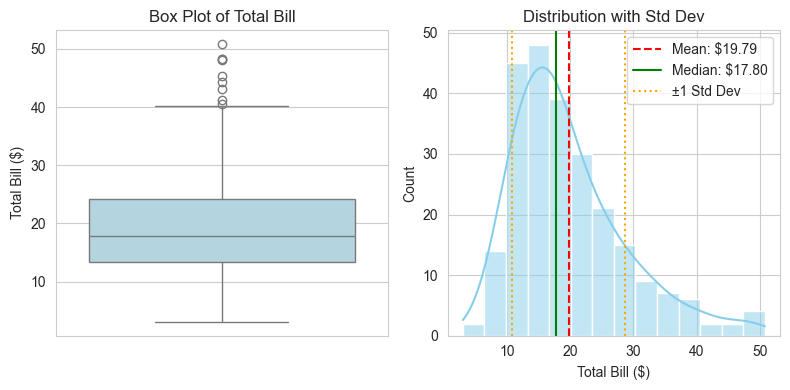

In [24]:
# Compute variance, std dev, and IQR on total_bill
col = df["total_bill"]

variance = np.var(col)
std_dev = np.std(col)
q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1

print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Q1 (25th percentile): ${q1:.2f}")
print(f"Q3 (75th percentile): ${q3:.2f}")
print(f"IQR: ${iqr:.2f}")
print("-" * 40)
print(f"Outlier bounds (1.5 × IQR):")
print(f"  Lower bound: ${q1 - 1.5*iqr:.2f}")
print(f"  Upper bound: ${q3 + 1.5*iqr:.2f}")

# Visualize with box plot
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=col, color="lightblue")
plt.title("Box Plot of Total Bill")
plt.ylabel("Total Bill ($)")

plt.subplot(1, 2, 2)
sns.histplot(col, kde=True, color="skyblue")
plt.axvline(col.mean(), color="red", linestyle="--", label=f"Mean: ${col.mean():.2f}")
plt.axvline(col.median(), color="green", linestyle="-", label=f"Median: ${col.median():.2f}")
plt.axvline(col.mean() + std_dev, color="orange", linestyle=":", label=f"±1 Std Dev")
plt.axvline(col.mean() - std_dev, color="orange", linestyle=":")
plt.legend()
plt.title("Distribution with Std Dev")
plt.xlabel("Total Bill ($)")
plt.tight_layout()
plt.show()

Mean of total_bill $19.79
Median of total_bill $17.80
Mode of total_bill $13.42


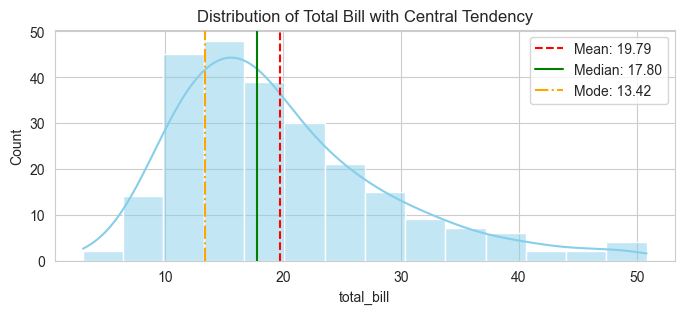

In [18]:
col = df["total_bill"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]

print(f"Mean of total_bill ${mean_val:.2f}")
print(f"Median of total_bill ${median_val:.2f}")
print(f"Mode of total_bill ${mode_val:.2f}")

# visualize the histogram to understand the distribution of "total_bill" column
plt.figure(figsize=(8,3))
sns.histplot(col, kde=True, color="skyblue")
plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="-", label=f"Median: {median_val:.2f}")
plt.axvline(mode_val, color="orange", linestyle="-.", label=f"Mode: {mode_val:.2f}")    
plt.legend()
plt.title("Distribution of Total Bill with Central Tendency")
plt.show()

**3. Measure of Spread**

Spread tells us how scattered the data is around the center.

In [21]:
# range
data_range = col.max() - col.min()
print(f"Range of total_bill: ${data_range:.2f}")

# variance
variance = np.var(col, ddof=1)  # sample variance
print(f"Variance of total_bill: {variance:.2f}")

# standard deviation
std_dev = np.sqrt(variance)
print(f"Standard Deviation of total_bill: {std_dev:.2f}")


# IQR - Inter Quartile Range
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)
iqr = Q3 - Q1
print(f"Inter Quartile Range (IQR) of total_bill: ${iqr:.2f}")

Range of total_bill: $47.74
Variance of total_bill: 79.25
Standard Deviation of total_bill: 8.90
Inter Quartile Range (IQR) of total_bill: $10.78


**4. Summary Statistics (df.describe)**

In [25]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Descriptive, Predictive, and Prescriptive Statistics**

**1. Descriptive Statistics**
- **What**: summarizes and describes data using mean, median, std dev, counts, etc.
- **Purpose**: understand the data you have (what happened in the past)
- **Use cases**: 
  - Reporting business metrics (average revenue, customer count)
  - Understanding customer demographics
  - Summarizing test results
  - Creating dashboards and reports
- **Example**: "Average bill is $20, median is $18, 75% of bills are under $25"
- **Tools**: mean, median, mode, variance, std dev, percentiles, histograms, box plots

**2. Predictive Statistics**
- **What**: uses historical data to forecast future outcomes (machine learning, regression, classification)
- **Purpose**: predict what will happen (future)
- **Use cases**:
  - Predicting customer churn (will they leave?)
  - Sales forecasting (how much will we sell next month?)
  - Credit risk assessment (will customer default?)
  - House price prediction
  - Disease diagnosis (does patient have illness?)
- **Example**: "Based on past data, customers with 3+ support tickets have 60% churn rate"
- **Tools**: linear regression, logistic regression, decision trees, neural networks, time series models

**3. Prescriptive Statistics**
- **What**: recommends actions based on data (optimization, decision-making)
- **Purpose**: decide what to do (actionable insights)
- **Use cases**:
  - Optimizing inventory (how much stock to keep?)
  - Resource allocation (which customer segment to prioritize?)
  - Pricing strategies (what price maximizes profit?)
  - Recommender systems (which product to show to user?)
  - Route optimization (best delivery route?)
- **Example**: "Increase marketing spend on segment X because they have highest lifetime value"
- **Tools**: optimization algorithms, simulations, A/B testing, linear programming

**Quick Summary**
- **Descriptive**: "What is happening?" (analyze past)
- **Predictive**: "What will happen?" (forecast future)
- **Prescriptive**: "What should we do?" (recommend action)

1. Descriptive Statistics
2. Predictive Statistics
3. Prescriptive Statistics 

Mean of tip $3.00
Median of tip $2.90
Mode of tip $2.00


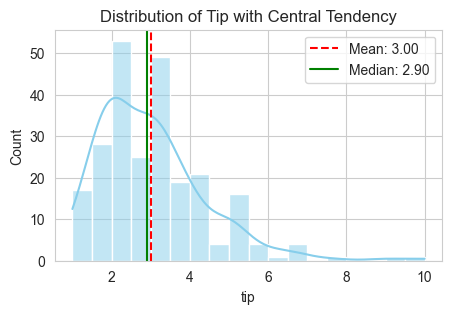

In [26]:
col = df["tip"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]

print(f"Mean of tip ${mean_val:.2f}")
print(f"Median of tip ${median_val:.2f}")
print(f"Mode of tip ${mode_val:.2f}")

# visualize the histogram to understand the distribution of "total_bill" column
plt.figure(figsize=(5,3))
sns.histplot(col, kde=True, color="skyblue")
plt.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="-", label=f"Median: {median_val:.2f}")
plt.legend()
plt.title("Distribution of Tip with Central Tendency")
plt.show()

6. Data Distribution & Skewness
7. Outlier Detection
8. Correlation analysis

**6. Data Distribution & Skewness**

In [27]:
print(df["tip"].skew())
print(df["total_bill"].skew())

1.4654510370979401
1.1332130376158205


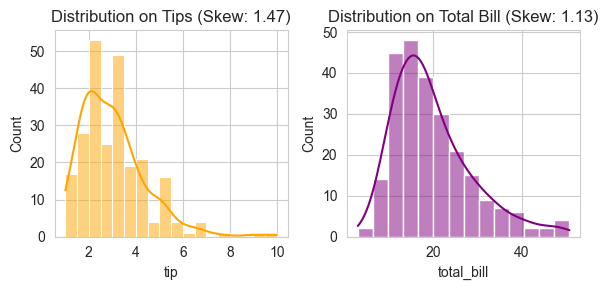

Interpretation:
Skewness = 0: Perfectly Normal
Skewness > 0: Right Skewed (Tail is on the right)
Skewness < 0: Left Skewed (Tail is on the left)


In [31]:
plt.figure(figsize=(6,3))

# plot 1: Tip Distribution
plt.subplot(1, 2, 1)
sns.histplot(df["tip"], kde=True, color="orange")
plt.title(f"Distribution on Tips (Skew: {df["tip"].skew():.2f})")

# plot 2: Total Bill Distribution
plt.subplot(1, 2, 2)
sns.histplot(df["total_bill"], kde=True, color="purple")
plt.title(f"Distribution on Total Bill (Skew: {df["total_bill"].skew():.2f})")

plt.tight_layout()
plt.show()


print("Interpretation:")
print("Skewness = 0: Perfectly Normal")
print("Skewness > 0: Right Skewed (Tail is on the right)")
print("Skewness < 0: Left Skewed (Tail is on the left)")


**KDE (Kernel Density Estimation)**

KDE is a smooth curve that estimates the distribution of a numeric variable. It helps you see the shape of the data more clearly than bars alone.

**Why it is useful:**
- Shows the overall shape of a distribution
- Helps spot skewness, peaks, and multiple clusters
- Makes it easier to compare numeric variables visually

**In this notebook:** when `kde=True` is used in `sns.histplot(...)`, Seaborn draws this smooth density curve on top of the histogram.

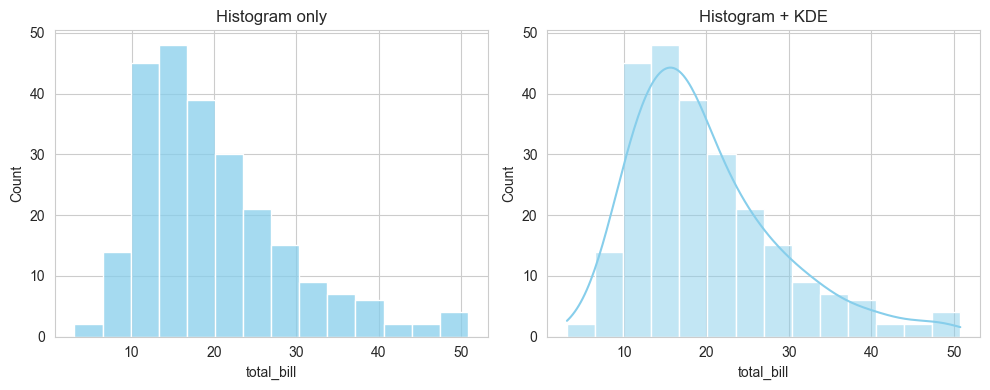

In [29]:
# Compare histogram with and without KDE for the total_bill column
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["total_bill"], color="skyblue", kde=False)
plt.title("Histogram only")
plt.xlabel("total_bill")

plt.subplot(1, 2, 2)
sns.histplot(df["total_bill"], color="skyblue", kde=True)
plt.title("Histogram + KDE")
plt.xlabel("total_bill")

plt.tight_layout()
plt.show()

**7. Outlier Detection**

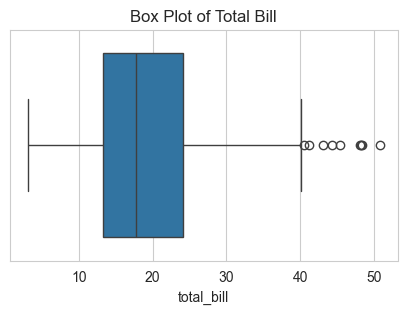

Lower Bound: -2.8224999999999945
Upper Bound: 40.29749999999999
Number of outliers: 9


In [32]:
# 1. Visual method
plt.figure(figsize=(5, 3))
sns.boxplot(x=df["total_bill"])
plt.title("Box Plot of Total Bill")
plt.show()


# formula method
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)

# filter outliers
outliers = df[(df["total_bill"] < lower_bound) | (df["total_bill"] > upper_bound)]
print("Number of outliers:", len(outliers))

In [33]:
outliers

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


**8. Correlation Analysis**

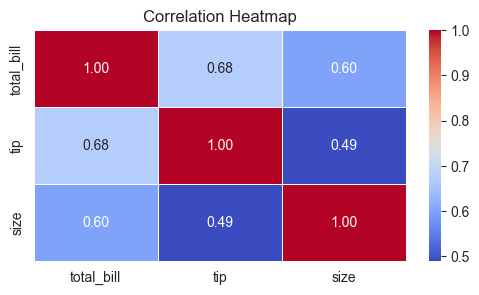


Correlation between Total Bill and Tip:
0.6757341092113647


In [34]:
# calculate correlation matrix 
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Visualize with Heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

print("\nCorrelation between Total Bill and Tip:")
print(corr_matrix.loc['total_bill', 'tip'])